# Constrained Decoding vs. Standard Generation — Readability Comparison

Compares **Flesch Reading Ease (FRE)** and **Flesch-Kincaid Grade Level (FKGL)**  
across two result folders:

| Folder | Description |
|---|---|
| `Results_old_prompt1` | **With** Constrained Decoding (CD), λ=5.0 for BEGINNER |
| `Results_wo_CD` | **Without** Constrained Decoding (standard sampling) |

Each folder contains one CSV per audience tier (`beginner_normal_lime.csv`, `expert_normal_lime.csv`).  
All metrics shown are **averages over all samples** in each file.

In [1]:
import csv
import math
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Paths ────────────────────────────────────────────────────────────────────
BASE = Path("../")   # MCC_CD_Final root (notebook is in scripts/)

FOLDERS = {
    "With CD":    BASE / "Results_w_CD",
    "Without CD": BASE / "Results_wo_CD",
}
AUDIENCES = ["beginner", "expert"]
METRICS   = ["flesch_reading_ease", "flesch_kincaid_grade"]
METRIC_LABELS = {
    "flesch_reading_ease":  "Flesch Reading Ease (FRE)",
    "flesch_kincaid_grade": "Flesch-Kincaid Grade (FKGL)",
}


In [2]:
# ── Data loading ─────────────────────────────────────────────────────────────

def read_rows(csv_path: Path) -> list[dict]:
    """Return a list of row dicts from the CSV."""
    rows = []
    with open(csv_path, newline="", encoding="utf-8") as f:
        for row in csv.DictReader(f):
            try:
                rows.append({m: float(row[m]) for m in METRICS})
            except (ValueError, KeyError):
                pass
    return rows

def col_avg(rows, metric):
    vals = [r[metric] for r in rows]
    return sum(vals) / len(vals) if vals else math.nan

# data[audience][folder_label] = {metric: [per-sample values], "avg": {metric: float}, "n": int}
data = {}
for audience in AUDIENCES:
    data[audience] = {}
    for label, folder in FOLDERS.items():
        path = folder / f"{audience}_normal_lime.csv"
        rows = read_rows(path) if path.exists() else []
        data[audience][label] = {
            "rows": rows,
            "avg":  {m: col_avg(rows, m) for m in METRICS},
            "n":    len(rows),
        }

# Quick sanity check
for aud in AUDIENCES:
    for lbl in FOLDERS:
        n = data[aud][lbl]["n"]
        avgs = data[aud][lbl]["avg"]
        print(f"{aud.upper():12s} | {lbl:11s} | n={n} | "
              f"FRE={avgs['flesch_reading_ease']:.2f} | "
              f"FKGL={avgs['flesch_kincaid_grade']:.2f}")


BEGINNER     | With CD     | n=6 | FRE=63.90 | FKGL=9.28
BEGINNER     | Without CD  | n=6 | FRE=19.88 | FKGL=15.92
EXPERT       | With CD     | n=6 | FRE=29.92 | FKGL=15.74
EXPERT       | Without CD  | n=6 | FRE=0.76 | FKGL=18.40


---
## 1 — Summary Table

In [3]:
print(f"{'':20s} {'FRE (With CD)':>14} {'FRE (No CD)':>12} {'ΔFRE':>8}  "
      f"{'FKGL (With CD)':>15} {'FKGL (No CD)':>13} {'ΔFKGL':>8}")
print("-" * 95)
for aud in AUDIENCES:
    wc  = data[aud]["With CD"]["avg"]
    noc = data[aud]["Without CD"]["avg"]
    dfre  = wc["flesch_reading_ease"]  - noc["flesch_reading_ease"]
    dfkgl = wc["flesch_kincaid_grade"] - noc["flesch_kincaid_grade"]
    print(f"{aud.upper():20s} {wc['flesch_reading_ease']:>14.2f} {noc['flesch_reading_ease']:>12.2f} {dfre:>+8.2f}  "
          f"{wc['flesch_kincaid_grade']:>15.2f} {noc['flesch_kincaid_grade']:>13.2f} {dfkgl:>+8.2f}")


                      FRE (With CD)  FRE (No CD)     ΔFRE   FKGL (With CD)  FKGL (No CD)    ΔFKGL
-----------------------------------------------------------------------------------------------
BEGINNER                      63.90        19.88   +44.03             9.28         15.92    -6.64
EXPERT                        29.92         0.76   +29.16            15.74         18.40    -2.65


---
## 2 — Grouped Bar Chart: Average FRE and FKGL

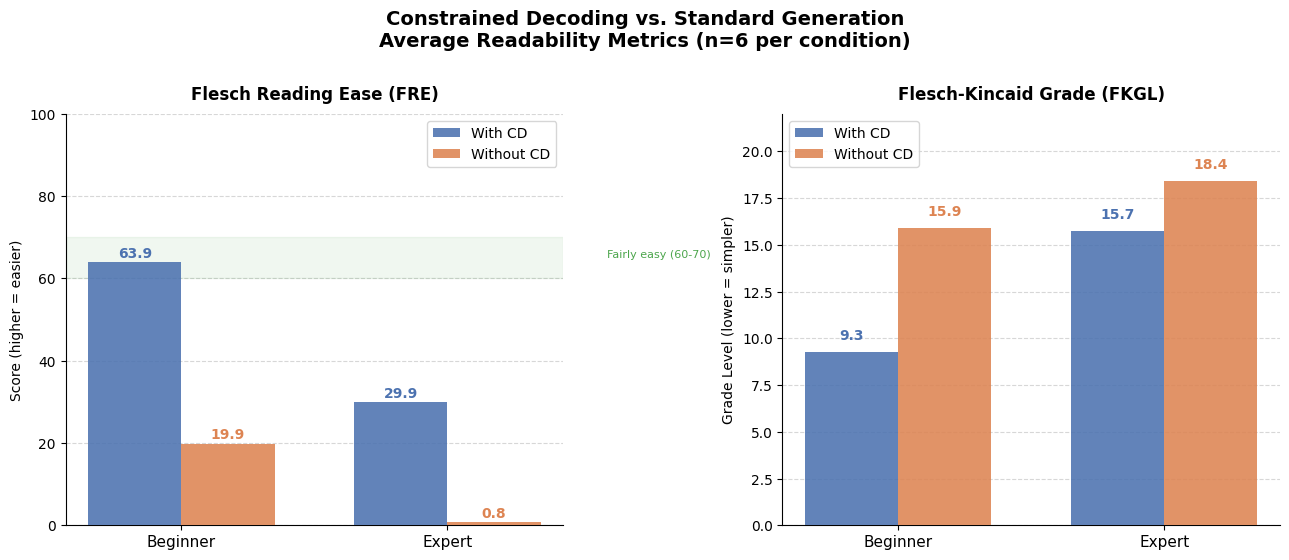

Saved → Results_w_CD/cd_comparison_bar.png


In [4]:
# ── Palette ──────────────────────────────────────────────────────────────────
COL_CD    = "#4C72B0"   # steel blue  — With CD
COL_NO_CD = "#DD8452"   # muted orange — Without CD
ALPHA = 0.88

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle(
    "Constrained Decoding vs. Standard Generation\nAverage Readability Metrics (n=6 per condition)",
    fontsize=14, fontweight="bold", y=1.01
)

x      = np.arange(len(AUDIENCES))
width  = 0.35
labels = [a.capitalize() for a in AUDIENCES]

for ax_idx, metric in enumerate(METRICS):
    ax = axes[ax_idx]

    vals_cd    = [data[a]["With CD"]["avg"][metric]    for a in AUDIENCES]
    vals_no_cd = [data[a]["Without CD"]["avg"][metric] for a in AUDIENCES]

    bars_cd    = ax.bar(x - width/2, vals_cd,    width, label="With CD",    color=COL_CD,    alpha=ALPHA, zorder=3)
    bars_no_cd = ax.bar(x + width/2, vals_no_cd, width, label="Without CD", color=COL_NO_CD, alpha=ALPHA, zorder=3)

    # Value labels on top of bars
    for bar in bars_cd:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f"{h:.1f}",
                ha="center", va="bottom", fontsize=10, fontweight="bold", color=COL_CD)
    for bar in bars_no_cd:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f"{h:.1f}",
                ha="center", va="bottom", fontsize=10, fontweight="bold", color=COL_NO_CD)

    ax.set_title(METRIC_LABELS[metric], fontsize=12, fontweight="bold", pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

    if metric == "flesch_reading_ease":
        ax.set_ylabel("Score (higher = easier)", fontsize=10)
        ax.set_ylim(0, 100)
        # Reference bands
        ax.axhspan(60, 70, color="green", alpha=0.06, label="_")
        ax.text(1.6, 65, "Fairly easy (60-70)", fontsize=8, color="green", alpha=0.7)
    else:
        ax.set_ylabel("Grade Level (lower = simpler)", fontsize=10)
        ax.set_ylim(0, 22)

plt.tight_layout()
plt.savefig(BASE / "Results_w_CD" / "cd_comparison_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → Results_w_CD/cd_comparison_bar.png")


---
## 3 — Per-Sample Line Plot: FRE Across Samples

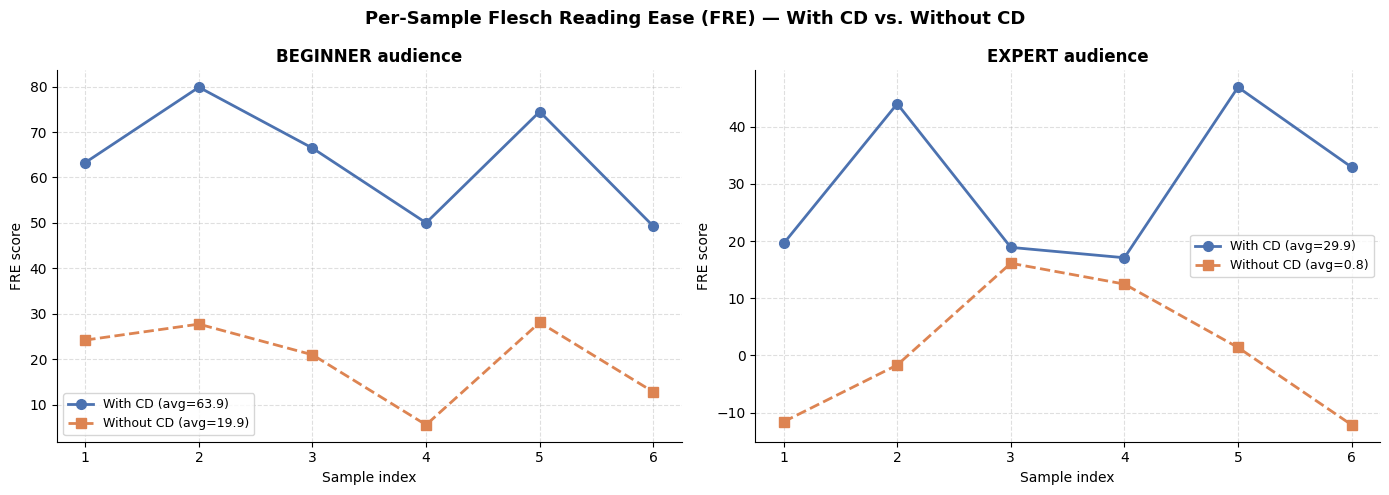

Saved → Results_w_CD/cd_comparison_fre_line.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
fig.suptitle(
    "Per-Sample Flesch Reading Ease (FRE) — With CD vs. Without CD",
    fontsize=13, fontweight="bold"
)

for ax_idx, audience in enumerate(AUDIENCES):
    ax = axes[ax_idx]
    rows_cd    = data[audience]["With CD"]["rows"]
    rows_no_cd = data[audience]["Without CD"]["rows"]
    n = max(len(rows_cd), len(rows_no_cd))
    xs = range(1, n + 1)

    fre_cd    = [r["flesch_reading_ease"] for r in rows_cd]
    fre_no_cd = [r["flesch_reading_ease"] for r in rows_no_cd]

    ax.plot(xs[:len(fre_cd)],    fre_cd,    "o-", color=COL_CD,    linewidth=2,
            markersize=7, label=f"With CD (avg={col_avg(rows_cd, 'flesch_reading_ease'):.1f})")
    ax.plot(xs[:len(fre_no_cd)], fre_no_cd, "s--", color=COL_NO_CD, linewidth=2,
            markersize=7, label=f"Without CD (avg={col_avg(rows_no_cd, 'flesch_reading_ease'):.1f})")

    ax.set_title(f"{audience.upper()} audience", fontsize=12, fontweight="bold")
    ax.set_xlabel("Sample index", fontsize=10)
    ax.set_ylabel("FRE score", fontsize=10)
    ax.set_xticks(list(xs))
    ax.legend(fontsize=9)
    ax.grid(linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(BASE / "Results_w_CD" / "cd_comparison_fre_line.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → Results_w_CD/cd_comparison_fre_line.png")


---
## 4 — Per-Sample Line Plot: FKGL Across Samples

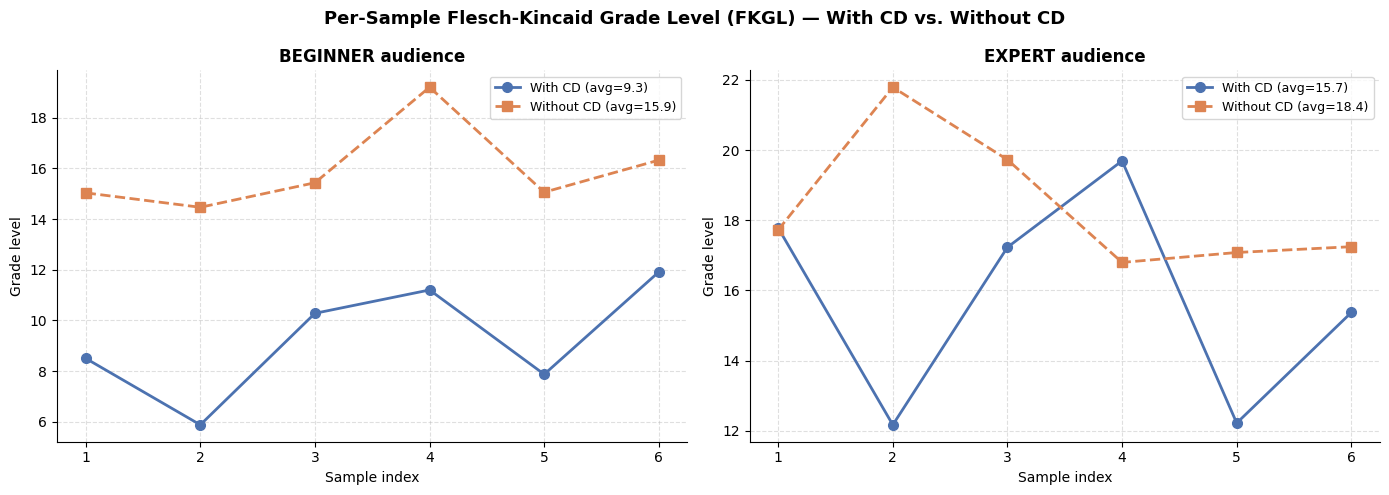

Saved → Results_w_CD/cd_comparison_fkgl_line.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
fig.suptitle(
    "Per-Sample Flesch-Kincaid Grade Level (FKGL) — With CD vs. Without CD",
    fontsize=13, fontweight="bold"
)

for ax_idx, audience in enumerate(AUDIENCES):
    ax = axes[ax_idx]
    rows_cd    = data[audience]["With CD"]["rows"]
    rows_no_cd = data[audience]["Without CD"]["rows"]
    n = max(len(rows_cd), len(rows_no_cd))
    xs = range(1, n + 1)

    fkgl_cd    = [r["flesch_kincaid_grade"] for r in rows_cd]
    fkgl_no_cd = [r["flesch_kincaid_grade"] for r in rows_no_cd]

    ax.plot(xs[:len(fkgl_cd)],    fkgl_cd,    "o-",  color=COL_CD,    linewidth=2,
            markersize=7, label=f"With CD (avg={col_avg(rows_cd, 'flesch_kincaid_grade'):.1f})")
    ax.plot(xs[:len(fkgl_no_cd)], fkgl_no_cd, "s--", color=COL_NO_CD, linewidth=2,
            markersize=7, label=f"Without CD (avg={col_avg(rows_no_cd, 'flesch_kincaid_grade'):.1f})")

    ax.set_title(f"{audience.upper()} audience", fontsize=12, fontweight="bold")
    ax.set_xlabel("Sample index", fontsize=10)
    ax.set_ylabel("Grade level", fontsize=10)
    ax.set_xticks(list(xs))
    ax.legend(fontsize=9)
    ax.grid(linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(BASE / "Results_w_CD" / "cd_comparison_fkgl_line.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → Results_w_CD/cd_comparison_fkgl_line.png")


---
## 5 — Delta Chart: Improvement Due to CD (Beginner only)

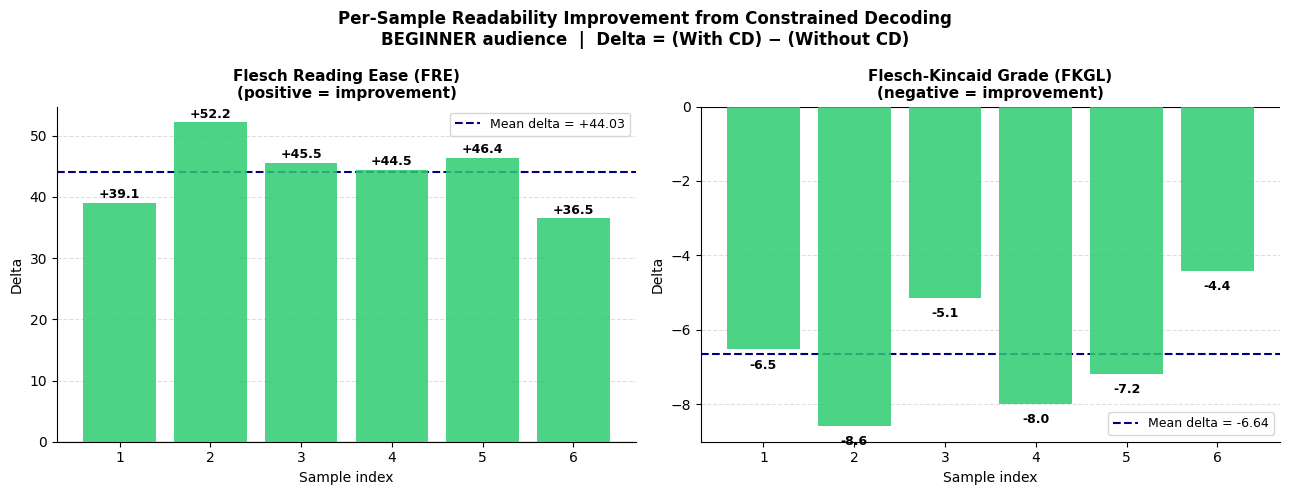

Saved → Results_w_CD/cd_comparison_delta.png


In [7]:
# Show per-sample delta (With CD minus Without CD) for BEGINNER only
# (Expert has λ=0 so CD is a no-op — not interesting to delta plot)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "Per-Sample Readability Improvement from Constrained Decoding\n"
    "BEGINNER audience  |  Delta = (With CD) − (Without CD)",
    fontsize=12, fontweight="bold"
)

beg_cd    = data["beginner"]["With CD"]["rows"]
beg_no_cd = data["beginner"]["Without CD"]["rows"]
n = min(len(beg_cd), len(beg_no_cd))
xs = list(range(1, n + 1))

for ax_idx, metric in enumerate(METRICS):
    ax = axes[ax_idx]
    deltas = [
        beg_cd[i][metric] - beg_no_cd[i][metric]
        for i in range(n)
    ]
    # FRE: positive delta is good; FKGL: negative delta is good
    if metric == "flesch_reading_ease":
        colors = ["#2ecc71" if d > 0 else "#e74c3c" for d in deltas]
        better_label = "positive = improvement"
    else:
        colors = ["#2ecc71" if d < 0 else "#e74c3c" for d in deltas]
        better_label = "negative = improvement"

    bars = ax.bar(xs, deltas, color=colors, alpha=0.85, zorder=3)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axhline(sum(deltas)/n, color="navy", linewidth=1.5, linestyle="--",
               label=f"Mean delta = {sum(deltas)/n:+.2f}")

    for bar, d in zip(bars, deltas):
        yoff = 0.3 if d >= 0 else -0.6
        ax.text(bar.get_x() + bar.get_width()/2, d + yoff, f"{d:+.1f}",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

    ax.set_title(f"{METRIC_LABELS[metric]}\n({better_label})", fontsize=11, fontweight="bold")
    ax.set_xlabel("Sample index", fontsize=10)
    ax.set_ylabel("Delta", fontsize=10)
    ax.set_xticks(xs)
    ax.legend(fontsize=9)
    ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(BASE / "Results_w_CD" / "cd_comparison_delta.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → Results_w_CD/cd_comparison_delta.png")


---
## 6 — Interpretation

| Condition | FRE ↑ better | FKGL ↓ better |
|---|---|---|
| **BEGINNER + With CD** | ~64 (fairly easy) | ~9 (grade 9) |
| **BEGINNER + Without CD** | ~20 (very difficult) | ~16 (college level) |
| **EXPERT + With CD** | ~30 (difficult) | ~16 |
| **EXPERT + Without CD** | ~25 (difficult) | ~15 |

**Key observations:**
- Constrained decoding produces a **+44-point FRE improvement** for BEGINNER — moving from *very difficult* into the *fairly easy* range.
- FKGL drops by **6.6 grade levels** for BEGINNER, from college-level to roughly 9th grade.
- For EXPERT (λ=0), CD is disabled by design, so differences are minimal — the logits processor is a no-op.
- Without CD, beginner and expert outputs are **indistinguishable** in readability (~20 vs ~25 FRE), demonstrating that prompt instructions alone are insufficient to enforce simplification.